In [1]:
%cd ../.
import os, sys
sys.path.insert(0, os.path.abspath('../Scripts'))
sys.path.insert(0, os.path.expanduser('~/CDD_Vault_API/python'))  # CDD Vault API (get_df)

/home/gtamo/MS_ML


In [2]:
%load_ext autoreload
%autoreload 2

import re
import os
import pandas as pd
import numpy as np
import py3Dmol
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import csv
import pickle

from pathlib import Path
from rdkit import Chem
from rdkit.Chem import AllChem,rdFMCS
# import prolif as plf
from glob import glob
import meeko
import subprocess as sub
# from vina import Vina
import time
from tqdm import tqdm
tqdm.pandas()
import importlib
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.dummy import DummyClassifier
from sklearn.manifold import TSNE
from xgboost import XGBClassifier,XGBRegressor
from openTSNE import TSNE as oTSNE        # pip install openTSNE
import seaborn as sns
from scipy import stats
import csv, contextlib, threading, joblib
import joblib
from joblib import Parallel, delayed
from datetime import date
import yaml
from types import SimpleNamespace

# user defined modules
import Rdkit_tools as rdkit_tools
importlib.reload(rdkit_tools)
import Molecule as M
import ML_Reg as ML_Reg
import ML_Class as ML_Class
from MolViz3D import MolViz3D
import Statistics_tools as stats_tools
import python.functions as fn
from get_library import get_df   # CDD Vault collection export
# from tdc.multi_pred import DTI

In [3]:
## params — single source of truth in config/config.yaml.
## Loaded as a `config` namespace AND injected as globals, so both
## `config.RAW_PROTEOMICS_PATH` and bare `RAW_PROTEOMICS_PATH` work.

with open('config/config.yaml') as _f:
    _cfg = yaml.safe_load(_f)
config = SimpleNamespace(**_cfg)
globals().update(_cfg)
print(f'> loaded {len(_cfg)} params from config/config.yaml')

> loaded 33 params from config/config.yaml


## 0. Imports

In [4]:
%%time
## Px part 1
df_raw_20260429, MS20260429 = fn.load_proteomics_data(
    RAW_PROTEOMICS_PATH,
    CLEAN_PROTEOMICS_PATH,
    drop_plates=['Plate12', 'Plate15', 'Plate23'],
)

## Px part 2:
df_raw_20260520, MS20260520 = fn.load_proteomics_data(
    PX_20260520_DB,            # raw per-gene table (Database export) — was wrongly CDDVault
    PX_20260520_CDDVAULT,      # metadata table (Vault export: SMILES, Collections)
    drop_plates=['Plate12', 'Plate15', 'Plate23'],
    mode='cddvault',           # Collections recipe (drops PROTACs), join on 'Batch Molecule-Batch ID'
    collections=['AJ', 'AK'],
)

## Px part 3:
df_raw_20260529, MS20260529 = fn.load_proteomics_data(
    PX_20260529_DB,            # raw per-gene table (Database export) — was wrongly CDDVault
    PX_20260529_CDDVAULT,      # metadata table (Vault export: SMILES, Collections)
    drop_plates=['Plate12', 'Plate15', 'Plate23'],
    mode='cddvault',           # Collections recipe (drops PROTACs), join on 'Batch Molecule-Batch ID'
    collections=['AJ', 'AK'],
)
# manual formatting for 20260529 metadata:
MS20260529 = MS20260529.rename(columns={'Molecule-Batch ID':'Batch Molecule-Batch ID','Nr. Down':'MSData - Proteomics activities: Nr. Down',"Cmpd Activity"	: "MSData - Proteomics activities: Cmpd Activity"})
parts = MS20260529['Batch Molecule-Batch ID'].str.split('-', n=2, expand=True)
MS20260529['Molecule Name'] = parts[0] + '-' + parts[1]   # 'SRB-0000385'
MS20260529['batch']    = parts[2]                    # '001'

## Making final df_raw
df_raw = pd.concat([df_raw_20260429,df_raw_20260520,df_raw_20260529]).reset_index(drop=True)
df_raw[['genes']].drop_duplicates().to_csv('data/MS/Px_genes.csv')

## get comprehensive MS set
colskeep = ['Molecule Name','MSData - Proteomics activities: Nr. Down','origin',"MSData - Proteomics activities: Cmpd Activity"]
MS = pd.concat([MS20260429.assign(origin='MS20260429'),
                MS20260520.assign(origin='MS20260520'),
                MS20260529.assign(origin='MS20260529')]).reset_index(drop=True)[colskeep].rename(columns={'Molecule Name':'compound',
                                                                                                          'MSData - Proteomics activities: Nr. Down':'ndown',
                                                                                                          "MSData - Proteomics activities: Cmpd Activity":'activity'})
MS['date'] = pd.to_datetime(MS['origin'].str.replace('MS', ''))

del df_raw_20260429,df_raw_20260520,df_raw_20260529

> mode=serac | MS rows: 1,617 | join key: MSData - Proteomics activities: Molecule-Batch ID
> 1617 unique compounds
> Ligase(s) ['FBXO31']
> Cellline ['HepG2']
> df_raw dim: (19056753, 11)
> mode=cddvault | MS rows: 288 | join key: Batch Molecule-Batch ID
> Collections kept: ['AJ', 'AK']
> df_raw dim: (2470390, 11)
> mode=cddvault | MS rows: 372 | join key: Molecule-Batch ID
> Collections kept: ['AJ', 'AK']
> df_raw dim: (3077520, 11)
CPU times: user 57.3 s, sys: 17.5 s, total: 1min 14s
Wall time: 1min 30s


In [5]:
## OpenTargets disease scores for every gene seen in the proteomics data.
## Cached to parquet — re-run is instant. Delete the file (or change OT_CACHE)
## to force a recompute from the local bulk dump under data/external/opentarget/.

if os.path.exists(OT_CACHE):
    print(f'> loading cached {OT_CACHE}')
    ot_df = pd.read_parquet(OT_CACHE)
else:
    # normalise the gene column: explode multi-gene strings (peptides mapping to >1
    # protein), strip whitespace, drop empties / NaNs, dedupe.
    unique_genes = pd.DataFrame({
        'gene': (df_raw['genes'].dropna().astype(str)
                  .str.split(r'[;,|]', regex=True).explode()
                  .str.strip()
                  .replace('', pd.NA).dropna()
                  .unique())
    })
    print(f'> {len(unique_genes):,} unique gene symbols in df_raw')

    ot_df = fn.get_opentarget_disease_score(
        unique_genes, gene_col='gene',
        top_n=20,
        ot_root=OT_ROOT,
    )
    os.makedirs(os.path.dirname(OT_CACHE), exist_ok=True)
    ot_df.to_parquet(OT_CACHE, index=False)
    print(f'> wrote {OT_CACHE}')

print(f'> {len(ot_df):,} (target, disease) rows  /  '
      f'{ot_df["target_symbol"].nunique():,} targets resolved')
ot_df.head(2)

## disease areas of interest to big pharma:
PRIORITY = {
    # Annotations: flagship products per pharma, just to anchor priority intuition.
    'cancer or benign tumor',                       # universal — BMS Opdivo/Yervoy, Roche Herceptin/Tecentriq/Phesgo, NVS Kisqali/Kymriah/Pluvicto, Pfizer Ibrance/Padcev, Lilly Verzenio/Jaypirca
    'hematologic disease',                          # BMS Revlimid/Pomalyst (multiple myeloma), Pfizer Elrexfio, NVS Tasigna, Roche Hemlibra (haemophilia), Lilly Jaypirca
    'cardiovascular disease',                       # BMS Eliquis, NVS Entresto/Leqvio (PCSK9 siRNA), Pfizer Vyndaqel (TTR amyloidosis)
    'immune system disease',                        # BMS Zeposia/Sotyktu/Orencia, NVS Cosentyx/Xolair, Pfizer Xeljanz/Cibinqo, Lilly Olumiant/Taltz, Roche Actemra
    'musculoskeletal or connective tissue disease', # RA / lupus / psoriasis (overlaps immune) — BMS Orencia, NVS Cosentyx, Pfizer Xeljanz, Lilly Olumiant
    'nervous system disease',                       # NVS Kesimpta/Gilenya (MS), Roche Ocrevus/Evrysdi (MS, SMA), Lilly Kisunla (AD, donanemab), BMS Cobenfy (post-Karuna)
    'psychiatric disorder',                         # BMS Cobenfy (schizophrenia), Lilly historic SSRIs/atypicals, otherwise smaller pharma footprint
    'nutritional or metabolic disease',             # Lilly #1 (Mounjaro / Zepbound — obesity/T2D), Pfizer & NVS chasing GLP-1 follow-ons
    'endocrine system disease',                     # Lilly (hormone/metabolic overlap), oncology adjacency (hormone-driven cancers) for BMS/Roche
    'disorder of visual system',                  # ← uncomment for Roche specifically (Vabysmo/Lucentis ophthalmology franchise)
    'respiratory or thoracic disease',            # ← uncomment for COPD/asthma plays (NVS Xolair, GSK; not named-four core)
    'infectious disease',                         # ← uncomment for vaccines/antivirals (Pfizer Comirnaty/Paxlovid/Prevnar)
}
DROP = {'phenotype', 'measurement', 'biological_process',
        'animal disease', 'medical procedure'}

def is_pharma_relevant(ta_str):
    """Keep rows whose therapeutic_areas overlap PRIORITY and aren't pure DROP-only."""
    if not isinstance(ta_str, str) or not ta_str:
        return False
    tokens = set(ta_str.split('|'))
    return bool(tokens & PRIORITY) and bool(tokens - DROP)

ot_pharma = ot_df[ot_df['therapeutic_areas'].apply(is_pharma_relevant)].reset_index(drop=True)
print(f'> {len(ot_pharma):,} / {len(ot_df):,} (target, disease) rows pass the BMS-style filter')
print(f'> covers {ot_pharma["target_symbol"].nunique():,} unique targets')

# breakdown by which priority area each row hits (a row can hit multiple)
print('\nrows per priority area:')
for token in sorted(PRIORITY):
    n = ot_pharma['therapeutic_areas'].str.split('|').apply(lambda s: token in s).sum()
    print(f'  {n:>6,}  {token}')

ot_pharma.head(2)

## get target list
ot_df_rank = (ot_pharma.sort_values('overall_score',ascending=False).reset_index(drop=True).groupby('target_symbol').first().sort_values('overall_score',ascending=False).reset_index())
target_list = list(ot_df_rank[ot_df_rank['overall_score'] > 0.4]['target_symbol'])

## add pharma target lists: BOTH the small-molecule patent file (gene col) AND
## the BMS pipeline file (hgnc_symbol col), so every pharma/BMS target is included.
patents = list(pd.read_csv(PHARMA_PATENT_CSV)['gene'].dropna().unique())
bms     = list(pd.read_csv(BMS_GENES)['hgnc_symbol'].dropna().unique())
target_list += patents + bms

target_list = list(dict.fromkeys(target_list))   # de-dupe, keep order
print(f'> target_list: {len(target_list)} unique '
      f'(OT>0.4 + {len(set(patents))} patent + {len(set(bms))} BMS genes)')
len(target_list)

> loading cached output/MS/opentargets_target_disease.parquet
> 232,004 (target, disease) rows  /  11,584 targets resolved
> 78,935 / 232,004 (target, disease) rows pass the BMS-style filter
> covers 9,105 unique targets

rows per priority area:
  17,071  cancer or benign tumor
   3,890  cardiovascular disease
   2,504  disorder of visual system
   3,466  endocrine system disease
   3,416  hematologic disease
   3,938  immune system disease
   3,710  infectious disease
   8,708  musculoskeletal or connective tissue disease
  25,393  nervous system disease
   9,849  nutritional or metabolic disease
   1,704  psychiatric disorder
   2,357  respiratory or thoracic disease
> target_list: 6706 unique (OT>0.4 + 172 patent + 46 BMS genes)


6706

In [6]:
FBX_MEASURE  = pd.read_csv('data/advanteidge/20260601_FBX_MEASURE.csv')
FBX_MSSCORE  = pd.read_csv('data/advanteidge/20260601_FBX_MSSCORE.csv')
FBX_REPORT   = pd.read_csv('data/advanteidge/20260601_FBX_REPORT.csv')
target2R2_df = pd.read_csv(GENE_SAR_OUT).rename(columns={'gene':'genes'})

In [7]:
# target2R2_df.head(1)

In [8]:
FBX_MEASURE.head(2)

,id,pg,genes,uniquecontrast,logfc,pvalue,adjpval,significant,plate
0,77528642,A0A024RBG1;Q9NZJ9-2,NUDT4B;NUDT4,SRB.0000615.001_vs_SRB.0000615.001_complement_...,-0.094775,0.300308,0.999869,0,Pw50
1,77528643,A0A024RBG1;Q9NZJ9-2,NUDT4B;NUDT4,SRB.0000692.002_vs_SRB.0000692.002_complement_...,-0.152554,0.097588,0.696253,0,Pw50


In [9]:
FBX_MEASURE[ (FBX_MEASURE['uniquecontrast']=='SRB.0005999.001_vs_SRB.0005999.001_complement_Pw50') & (FBX_MEASURE['significant']==1) ]

,id,pg,genes,uniquecontrast,logfc,pvalue,adjpval,significant,plate
88666,77617308,P63146,UBE2B,SRB.0005999.001_vs_SRB.0005999.001_complement_...,-1.134905,1.865137e-10,0.000002,1,Pw50


In [10]:
## Volcano plot for one compound
if 11 < 3:
    agg = fn.plot_volcano_significant(
        FBX_MEASURE, 'SRB.0005999.001_vs_SRB.0005999.001_complement_Pw50','UBE2B',
        fc_thresh=1.0, p_thresh=0.05,
        xmin=-8.0, xmax=8.0,
        up_color=ACTIVE_C, down_color=SILENT_C,
    )

In [11]:
## remove plate and keep max ms_score associate with target
FBX_MSSCORE = (FBX_MSSCORE[~FBX_MSSCORE['plate'].isin(['Plate12', 'Plate15', 'Plate23'])]
               .sort_values('ms_score_percent',ascending=False)
               .reset_index(drop=True))
FBX_MSSCORE = FBX_MSSCORE.groupby('genes').head(1).reset_index(drop=True)[['uniquecontrast','genes','ms_score','association_score']]

## add R2 value, note that some genes will be missing due to assocation score < 0.4 ctf
FBX_MSSCORE = pd.merge(FBX_MSSCORE,target2R2_df[['genes','R2','pearson_r','pearson_p','spearman_r','spearman_p']]).sort_values('R2',ascending=False)
print(FBX_MSSCORE.shape)
FBX_MSSCORE.head(2)

(161, 9)


,uniquecontrast,genes,ms_score,association_score,R2,pearson_r,pearson_p,spearman_r,spearman_p
1,SRB.0000615.001_vs_SRB.0000615.001_complement_...,KDM1B,111.247261,0.377864,0.391383,0.625606,5.741936e-243,0.189511,1.651124e-19
57,SRB.0005861.001_vs_SRB.0005861.001_complement_...,TMEM242,8.195687,0.468538,0.337332,0.580803,4.451293e-195,0.555842,2.056488e-175


In [12]:
## getting the compound info, plate and activity level
parts = FBX_REPORT['srbnumber'].str.split('-', n=2, expand=True)
FBX_REPORT['Molecule Name'] = parts[0] + '-' + parts[1]   # 'SRB-0000385'
FBX_REPORT['batch']    = parts[2]                    # '001'
print(FBX_REPORT['activity'].unique())
FBX_REPORT.head(2)


<ArrowStringArray>
['Medium (11-25)', 'Low (2-10)', 'Silent', 'Single (1)', 'High (>25)']
Length: 5, dtype: str


,id,uniquecontrast,srbnumber,source,cell_line,condition,time,concentration,controls,plate,nr_down,activity,Molecule Name,batch
0,2856,SRB.0005840.001_vs_SRB.0005840.001_complement_...,SRB-0005840-001,SERAC,HepG2,WildType,24,10.0,NaN,Pw81BCDEKO,11,Medium (11-25),SRB-0005840,001
1,3127,SRB.0005518.001_vs_SRB.0005518.001_complement_...,SRB-0005518-001,SERAC,HepG2,WildType,24,10.0,NaN,Pw105VMMLN,8,Low (2-10),SRB-0005518,001


In [13]:
print(FBX_REPORT.shape)
len(FBX_REPORT['srbnumber'].unique())

(305, 14)


147

In [14]:
target2R2_df.head(2)

,genes,R2,nullR2,n,pearson_r,pearson_p,spearman_r,spearman_p
0,TP53,0.048538,0.0,2207,0.220313,1.148335e-25,0.170420,7.590317e-16
1,BRCA2,0.065382,0.0,2234,0.255700,1.108273e-34,0.158224,5.404622e-14


## 1. Build interface

In [15]:
## local params:
control_compounds = ['SRB-0000692','SRB-0000615']

In [16]:
## degradation research per target (one record/gene): therapeutic rationale,
## degrader feasibility, DepMap dependency, indications, safety, sources, ...
import json as _json
with open('/mnt/c/Users/gtamo/Desktop/GT/disease_association/20260604_degradation_research.json') as _f:
    RESEARCH_161_T_20260604 = _json.load(_f)
print(f'> loaded degradation research for {len(RESEARCH_161_T_20260604)} genes; '
      f'fields: {list(RESEARCH_161_T_20260604[0].keys())}')


> loaded degradation research for 161 genes; fields: ['gene_name', 'target_class', 'lof_therapeutic_benefit', 'degrader_vs_inhibitor_rationale', 'degrader_feasibility', 'depmap_dependency', 'opentargets_top_indications', 'existing_degraders', 'safety_flags', 'confidence', 'biology_rationale', 'sources']


In [17]:
## ============================================================
## 3D interface: R² × association_score × ms_score  (fn.plot_3d_interface)
##   • dots          = FBX_MSSCORE (one per gene), coloured by disease area
##                     with pharma-patent + BMS-pipeline overrides
##   • volcano source = FBX_MEASURE (per gene×experiment logfc/pvalue)
##   • compounds      = linked via FBX_REPORT.uniquecontrast → srbnumber
## For each target we list EVERY compound that significantly down-modulates it
## (logfc ≤ -1 & p ≤ 0.05 in any plate replicate), keeping the strongest-hit
## experiment for the volcano. The panel pages 5 compounds at a time (◀ ▶).
## ============================================================
DROP_PLATES = ['Plate12', 'Plate15', 'Plate23']

# chem library — SMILES for the structure thumbnails (key = SRB-XXXXXXX, no batch)
chemlib = pd.read_csv(CHEMLIB_PATH)[['compound', 'smiles']].drop_duplicates('compound')

# --- 1) highest-priority OpenTargets disease area per gene ---
if 'ot_df' not in globals():
    ot_df = pd.read_parquet(OT_CACHE)
PRIORITY = [
    'cancer or benign tumor', 'hematologic disease', 'cardiovascular disease',
    'immune system disease', 'musculoskeletal or connective tissue disease',
    'nervous system disease', 'psychiatric disorder',
    'nutritional or metabolic disease', 'endocrine system disease',
]
_rank = {a: i for i, a in enumerate(PRIORITY)}
_areas = (ot_df[['target_symbol', 'overall_score', 'disease_name', 'therapeutic_areas']]
          .assign(area=lambda d: d['therapeutic_areas'].fillna('').str.split('|'))
          .explode('area'))
_areas = _areas[_areas['area'].isin(_rank)].copy()
_areas['_rank'] = _areas['area'].map(_rank)
_top_area = (_areas.sort_values(['target_symbol', '_rank', 'overall_score'],
                                ascending=[True, True, False])
             .drop_duplicates('target_symbol', keep='first')
             .rename(columns={'target_symbol': 'gene', 'area': 'disease_area'})
             [['gene', 'disease_area']])

# --- 2) dots: FBX_MSSCORE + disease_area + pharma/BMS override (BMS supersedes) ---
iface_df = FBX_MSSCORE.rename(columns={'genes': 'gene'}).merge(_top_area, on='gene', how='left')
_pharma = set(pd.read_csv(PHARMA_PATENT_CSV)['gene'].dropna().unique())
_bms    = set(pd.read_csv(BMS_GENES)['hgnc_symbol'].dropna().unique())
_model  = iface_df['R2'] > PHARMA_R2_CUTOFF
iface_df.loc[iface_df['gene'].isin(_pharma) & _model, 'disease_area'] = 'pharma'
iface_df.loc[iface_df['gene'].isin(_bms)    & _model, 'disease_area'] = 'BMS'
print(f'> iface_df: {len(iface_df)} genes; '
      f'disease_area set for {iface_df["disease_area"].notna().sum()}')

# --- 3) per-target compound list from FBX_MEASURE + FBX_REPORT ---
meas = FBX_MEASURE[~FBX_MEASURE['plate'].isin(DROP_PLATES)]            # volcano source
# genes measured per experiment (matches the count plot_volcano used to show in its title)
n_genes = (meas.dropna(subset=['logfc', 'pvalue'])
           .groupby('uniquecontrast')['genes'].nunique().rename('n_genes'))
rep  = (FBX_REPORT[['uniquecontrast', 'srbnumber', 'plate', 'concentration', 'activity']]
        .drop_duplicates('uniquecontrast'))
_p = rep['srbnumber'].astype(str).str.split('-', n=2, expand=True)     # strip batch suffix
rep = rep.assign(compound=_p[0] + '-' + _p[1])                         # SRB-XXXXXXX (chemlib key)
_hit = meas.loc[(meas['significant'] == 1) & (meas['logfc'] < 0),
                ['genes', 'uniquecontrast', 'logfc', 'pvalue']]   # significantly DOWN-modulated (FBX flag); drop meas 'plate'
hits = _hit.merge(rep, on='uniquecontrast', how='left').rename(columns={'genes': 'gene'})
hits = hits[hits['compound'].notna() & hits['compound'].str.startswith('SRB-')]
# Keep ALL passing plates (one row per gene,compound,plate) so the panel can
# offer per-plate volcanoes + checkbox filtering. One row per (gene,compound,plate):
# strongest-hit uniquecontrast within that plate.
hits = hits.sort_values(['gene', 'compound', 'plate', 'logfc'])
compounds_df = (hits.groupby(['gene', 'compound', 'plate'], as_index=False).first()
                .merge(chemlib, on='compound', how='left')
                .merge(n_genes, on='uniquecontrast', how='left'))
compounds_df = compounds_df[['gene', 'compound', 'plate', 'activity', 'n_genes',
                             'uniquecontrast', 'logfc', 'smiles']]
_per_cmp = compounds_df.groupby(['gene', 'compound']).size()
print(f'> {len(compounds_df):,} (gene,compound,plate) rows; '
      f'{_per_cmp.shape[0]:,} (gene,compound) pairs across '
      f'{compounds_df["gene"].nunique():,} genes; '
      f'{int((_per_cmp > 1).sum()):,} pairs span >1 plate; '
      f'plates: {sorted(compounds_df["plate"].unique())}')

# --- 4) colours + must-show pharma/BMS, then render ---
DISEASE_AREA_COLORS = {
    'pharma': ACTIVE_C, 'BMS': '#BA09D9',
    'cancer or benign tumor': '#DD870E', 'hematologic disease': '#FF0000',
    'cardiovascular disease': "#FB008A", 'immune system disease': '#2A9D8F',
    'musculoskeletal or connective tissue disease': '#264653',
    'nervous system disease': '#963802', 'psychiatric disorder': '#000000',
    'nutritional or metabolic disease': '#17E804',
    'endocrine system disease': "#6EE5F5",
}
MUST_INCLUDE = sorted(iface_df.loc[iface_df['disease_area'].isin(['pharma', 'BMS']), 'gene'])

# control targets: genes whose significant-down compound(s) are ALL control compounds
_g2c = compounds_df.groupby('gene')['compound'].apply(set)
control_genes = sorted(g for g, cs in _g2c.items() if cs and cs <= set(control_compounds))
print(f'> {len(control_genes)} control targets (only hit by control compounds): {control_genes[:10]}{"..." if len(control_genes)>10 else ""}')

# per-gene degradation research (gene_name -> record) for the hover research box
gene_research = {r['gene_name']: r for r in RESEARCH_161_T_20260604}

fig, highlighted = fn.plot_3d_interface(
    iface_df,
    x_col='R2', y_col='association_score', z_col='ms_score',
    x_label='SAR predictability',
    y_label='association score',
    z_label='MS score',
    must_include=MUST_INCLUDE,
    top_n_highlight=40,
    compounds_df=compounds_df,           # all associated compounds, paginated
    volcano_source=meas,                 # FBX_MEASURE = volcano data
    volcano_key='uniquecontrast',
    page_size=5,
    range_sliders=True,            # R²/association/MS-score range gating (in-range = coloured)
    range_defaults={'y': 0.35},    # default association (y) lower handle at 0.35
    control_genes=control_genes,   # grey diamonds, legend 'control'
    gene_research=gene_research,   # per-gene degradation-research hover box
    volcano_significant=True,      # colour only significant targets in the volcanoes
    volcano_dir=os.path.join(DROPBOX_ML, 'interfaces', 'volcanoes'),  # cache PNGs next to the HTML; re-runs reuse them
    volcano_n_jobs=8, volcano_xlim=(-8, 8), volcano_size_px=350,
    disease_area_colors=DISEASE_AREA_COLORS,
    nb_display=False,
    html_path=os.path.join(DROPBOX_ML,'interfaces', '20260603_3d_interface_R2_assoc_ms.html'),
)


> iface_df: 161 genes; disease_area set for 159
> 4,844 (gene,compound,plate) rows; 4,332 (gene,compound) pairs across 2,256 genes; 390 pairs span >1 plate; plates: ['Pw105VMKO', 'Pw105VMMLN', 'Pw105VMWT', 'Pw50', 'Pw63', 'Pw64', 'Pw81BCDEKO', 'Pw81BCDEval', 'Pw82KO', 'Pw82WT']
> 31 control targets (only hit by control compounds): ['ABL2', 'AIG1', 'ANTXR2', 'AP1S2', 'ARID5B', 'BRMS1', 'CHSY1', 'COQ2', 'CSK', 'CTSL']...
> 161 / 161 genes after filtering (x=R2, y=association_score, z=ms_score)
  [highlight] corner-top-40=40, association_score>None: 0, must=3, union=40
  [range_sliders] panels built for all 161 plotted genes
> long-format panel: 423 compound entries across 161 genes with compounds (page_size=5, 10 plates)
> built 423 structure thumbnails across 161 genes (png=423, rdkit=0, missing=0)
> volcanoes: 491 cached, 0 rendered [interactive SVG] -> /mnt/c/Users/gtamo/Serac Biosciences Dropbox/Serac_team/4_Data_Sciences/15_ML/interfaces/volcanoes
  [range_sliders] default box ≈ 41 

In [18]:
## extract the list of relevant targets: 
FBX_MSSCORE[['genes']].to_csv('output/interface/20260604_genes_poc.csv',index=False,sep=',')

## 2. Get cell signature

In [19]:
## Gene-function explanation from the local cell-signature annotations
## (built by python/build_cell_signature_annotations.py -> output/cell_signature/).
## protein_function = UniProt name/features; gene2term = GO BP/MF/CC + Reactome.
_FUNC = pd.read_parquet('output/cell_signature/protein_function.parquet').set_index('gene')
_G2T  = pd.read_parquet('output/cell_signature/gene2term.parquet')
_TSIZE = _G2T.groupby('term_id')['gene'].nunique()   # term breadth -> rank specific first

def explain_gene(gene, n=6):
    """Concise functional summary for a gene: protein name + UniProt features +
    the most-specific GO / Reactome terms (GO is propagated, so we sort by term
    breadth to surface informative leaves over broad ancestors)."""
    print(f'=== {gene} ===')
    if gene in _FUNC.index:
        r = _FUNC.loc[gene]
        tag = ', reviewed' if r.reviewed else ''
        print(f'{r.protein_name}  (UniProt {r.uniprot}{tag})')
        feats = [lbl for lbl, flag in [
            ('transmembrane', r.transmembrane), ('signal peptide', r.signal_peptide),
            ('DNA-binding', r.dna_binding), ('nucleotide-binding', r.nucleotide_binding),
            ('zinc finger', r.zinc_finger), ('catalytic site', r.catalytic)] if flag]
        if feats:    print('  features:', ', '.join(feats))
        if r.pfam:   print('  Pfam:', r.pfam)
        if r.domains:print('  domains:', r.domains)
    else:
        print('  (no protein-function annotation)')
    g = (_G2T[_G2T['gene'] == gene]
         .assign(_sz=lambda d: d['term_id'].map(_TSIZE))
         .sort_values('_sz'))   # most-specific terms first
    for coll, label in [('GO_BP', 'GO process'), ('GO_MF', 'GO function'),
                        ('GO_CC', 'GO location'), ('Reactome', 'Reactome')]:
        terms = g.loc[g['collection'] == coll, 'term_name'].tolist()
        if terms:
            more = ' ...' if len(terms) > n else ''
            print(f'  {label} ({len(terms)}): ' + '; '.join(terms[:n]) + more)

explain_gene('RAD51')


=== RAD51 ===
DNA repair protein RAD51 homolog 1  (UniProt Q06609;B0FXP0;B2R8T6;Q6FHX9;Q6ZNA8;Q9BV60, reviewed)
  domains: ,HhH,,48,77,
  GO process (109): response to glucoside; mitotic recombination-dependent replication fork processing; cell cycle DNA replication maintenance of fidelity; mitotic DNA replication maintenance of fidelity; cellular response to cisplatin; cellular response to camptothecin ...
  GO function (43): DNA strand exchange activity; ATP-dependent DNA damage sensor activity; DNA damage sensor activity; DNA polymerase binding; molecular sensor activity; nucleosome binding ...
  GO location (45): presynaptic intermediate filament cytoskeleton; presynaptic cytoskeleton; lateral element; intermediate filament cytoskeleton; condensed nuclear chromosome; nuclear ubiquitin ligase complex ...
  Reactome (29): Defective HDR through Homologous Recombination Repair (HRR) due to PALB2 loss of BRCA2/RAD51/RAD51C binding function; Defective homologous recombination repair (HRR

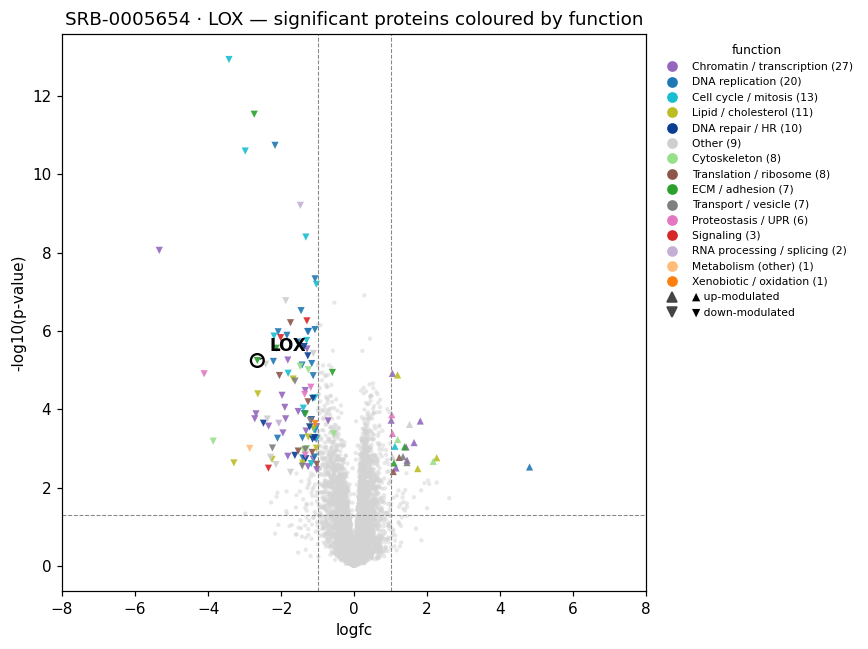

In [20]:
## ── Volcano coloured by protein FUNCTION (not just up/down) ───────────────
## Same significant-gene volcano as in the 3D interface, but every significant
## protein is coloured by its coarse functional category (fn.categorize_genes,
## derived from the GO/Reactome annotations) and DIRECTION is shown by marker
## shape: ▲ up-modulated, ▼ down-modulated. Lets you read the cell response off
## the plot — e.g. a down-cluster of DNA-replication / chromatin / translation.
## Example: compound SRB-0005654, target LOX (lysyl oxidase, ECM / adhesion).
gene_category = fn.categorize_genes(_G2T)        # {gene: functional category}

_meas = FBX_MEASURE[~FBX_MEASURE['plate'].isin(DROP_PLATES)]
_rep  = FBX_REPORT[['uniquecontrast', 'srbnumber', 'plate']].drop_duplicates('uniquecontrast')
_p    = _rep['srbnumber'].astype(str).str.split('-', n=2, expand=True)
_rep  = _rep.assign(compound=_p[0] + '-' + _p[1])               # SRB-XXXXXXX (strip batch)
_uc   = _rep.loc[(_rep['compound'] == 'SRB-0005654') & (_rep['plate'] == 'Pw82KO'),
                 'uniquecontrast'].iloc[0]

fig, ax = plt.subplots(figsize=(8, 6), dpi=110)
_agg = fn.plot_volcano_significant(
    _meas, _uc, 'LOX',
    gene_category=gene_category, category_colors=fn.CATEGORY_COLORS,
    xmin=-8, xmax=8, ax=ax,
    title='SRB-0005654 · LOX — significant proteins coloured by function')
plt.show()


In [21]:
## ── Qualify the cell response: ORA (hypergeometric) + GSEA-preranked ──────
## Two complementary enrichment tests on the SAME volcano (_uc above):
##   • ORA  — hypergeometric (Fisher) over the THRESHOLDED significant set
##            (down / up separately), measured proteome as background, BH-FDR.
##            Maps 1:1 onto the coloured points in the volcano above.
##   • GSEA — threshold-free: ranks ALL measured proteins by
##            sign(logfc)·-log10(p) and tests concentration at top/bottom.
##            Catches coordinated subtle shifts no single gene clears the cutoff for.
## Processes called by BOTH tests are the trustworthy story.
_sub = _meas[_meas['uniquecontrast'] == _uc].dropna(subset=['genes', 'logfc', 'pvalue'])
_a   = _sub.groupby('genes').agg(logfc=('logfc', 'mean'), pvalue=('pvalue', 'min'),
                                 sig=('significant', 'max')).reset_index()
_bg   = set(_a['genes'])
_down = set(_a.loc[(_a.sig > 0) & (_a.logfc < 0), 'genes'])
_up   = set(_a.loc[(_a.sig > 0) & (_a.logfc > 0), 'genes'])
_ranks = pd.Series((np.sign(_a.logfc) * -np.log10(_a.pvalue.clip(lower=1e-300))).values,
                   index=_a['genes'])

ora_down = fn.ora_enrichment(_down, _bg, _G2T, fdr=0.05, top_n=10)
ora_up   = fn.ora_enrichment(_up,   _bg, _G2T, fdr=0.05, top_n=10)
gsea     = fn.gsea_preranked(_ranks, _G2T, n_perm=1000, seed=0)   # ~1 min (permutation null)

def _show(title, df, cols):
    print(title)
    print(df[cols].to_string(index=False) if len(df) else '  (none)'); print()

print(f'SRB-0005654 · Pw82KO  —  measured {len(_bg)}, down {len(_down)}, up {len(_up)}\n')
_show('ORA  ▼ DOWN  (hypergeometric, FDR<0.05)', ora_down, ['collection', 'term_name', 'k', 'K', 'fdr'])
_show('ORA  ▲ UP    (hypergeometric, FDR<0.05)', ora_up,   ['collection', 'term_name', 'k', 'K', 'fdr'])
_show('GSEA ▼ suppressed (NES<0, FDR<0.05)',
      gsea[(gsea.direction == 'down') & (gsea.fdr < 0.05)].head(10), ['collection', 'term_name', 'NES', 'fdr'])
_show('GSEA ▲ induced    (NES>0, FDR<0.05)',
      gsea[(gsea.direction == 'up') & (gsea.fdr < 0.05)].head(10), ['collection', 'term_name', 'NES', 'fdr'])


SRB-0005654 · Pw82KO  —  measured 7925, down 109, up 24

ORA  ▼ DOWN  (hypergeometric, FDR<0.05)
collection                                                                                                            term_name  k  K      fdr
  Reactome                                                                           Homologous DNA Pairing and Strand Exchange  7 32 0.000036
     GO_BP                                                                           mitotic G2 DNA damage checkpoint signaling  6 27 0.000059
  Reactome                                                      Presynaptic phase of homologous DNA pairing and strand exchange  6 29 0.000059
     GO_BP                                                                                   DNA integrity checkpoint signaling  9 81 0.000059
  Reactome                                        Defective homologous recombination repair (HRR) due to BRCA2 loss of function  6 30 0.000059
  Reactome                                   

In [ ]:
## ── Enrichment score per FUNCTION (the 15 categories as gene sets) ────────
## Roll the per-GO/Reactome enrichment up to the coarse functions: feed the
## {gene: function} map (gene_category, from the volcano cell above) as gene
## sets to BOTH tests, so each FUNCTION gets one ORA p/FDR and one GSEA NES/FDR.
## Categories are large sets -> relax the size caps.
g2cat   = fn.gene_category_long(gene_category)
ora_fn  = fn.ora_enrichment(_down, _bg, g2cat, collections=('Function',),
                            min_overlap=3, max_term_size=10**9)
gsea_fn = fn.gsea_preranked(_ranks, g2cat, collections=('Function',),
                            min_size=5, max_size=10**9, n_perm=1000)

func_enrich = (gsea_fn[['term_name', 'size', 'NES', 'fdr', 'direction']]
               .rename(columns={'term_name': 'function', 'fdr': 'gsea_fdr'})
               .merge(ora_fn[['term_name', 'k', 'K', 'fdr']]
                      .rename(columns={'term_name': 'function', 'k': 'down_n',
                                       'K': 'category_size', 'fdr': 'ora_down_fdr'}),
                      on='function', how='left')
               .sort_values('NES'))
print(f'SRB-0005654 · Pw82KO — enrichment per function (GSEA NES + ORA-down FDR):')
func_enrich[func_enrich['function'] != 'Other'].reset_index(drop=True)
